# Random Forest Model for Amazon Reviews Sentiment Analysis

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import time
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings('ignore')
# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

True

## Step 1: Data Loading and Exploration

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# Load the balanced dataset
path = "/content/drive/MyDrive/data/raw/train.csv"
column_names = ['target', 'title_review', 'content_review']
df = pd.read_csv(path, header=None, names=column_names, dtype=str, nrows=80000)
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Dataset shape: (80000, 3)

First few rows:
  target                                       title_review  \
0      2                     Stuning even for the non-gamer   
1      2              The best soundtrack ever to anything.   
2      2                                           Amazing!   
3      2                               Excellent Soundtrack   
4      2  Remember, Pull Your Jaw Off The Floor After He...   

                                      content_review  
0  This sound track was beautiful! It paints the ...  
1  I'm reading a lot of reviews saying that this ...  
2  This soundtrack is my favorite music of all ti...  
3  I truly like this soundtrack and I enjoy video...  
4  If you've played the game, you know how divine...  

Data types:
target            object
title_review      object
content_review    object
dtype: object

Missing values:
target            0
title_review      5
content_review    0
dtype: int64


## Step 2: Text Preprocessing Function

In [7]:
def preprocess_text(text):
    """
    Preprocess text: lowercase, remove special characters, remove stopwords, tokenize
    """
    # Convert to lowercase
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Tokenization and stopword removal
    stop_words = set(stopwords.words('english'))
    try:
        tokens = word_tokenize(text)
        tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
        text = ' '.join(tokens)
    except:
        pass
    return text
# Test preprocessing
print("Testing preprocessing:")
sample_text = df['content_review'].iloc[0]
print(f"Original: {sample_text[:100]}")
print(f"Preprocessed: {preprocess_text(sample_text)[:100]}")

Testing preprocessing:
Original: This sound track was beautiful! It paints the senery in your mind so well I would recomend it even t
Preprocessed: this sound track was beautiful it paints the senery in your mind so well i would recomend it even to


## Step 3: Apply Preprocessing to Dataset

In [8]:
# Combine title and content for better features
df['combined_text'] = df['title_review'].fillna('') + ' ' + df['content_review'].fillna('')
# Apply preprocessing
print("Preprocessing text data...")
df['processed_text'] = df['combined_text'].apply(preprocess_text)
# Remove empty rows after preprocessing
df = df[df['processed_text'].str.len() > 0].reset_index(drop=True)
print(f"Dataset shape after preprocessing: {df.shape}")
# Convert target to numeric
df['target'] = df['target'].astype(int)
print(f"\nClass distribution:\n{df['target'].value_counts()}")

Preprocessing text data...
Dataset shape after preprocessing: (80000, 5)

Class distribution:
target
2    41015
1    38985
Name: count, dtype: int64


## Step 4: Feature Engineering - TF-IDF Vectorization

In [9]:
# Split data first (before vectorization to avoid data leakage)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['processed_text'],
    df['target'],
    test_size=0.2,
    random_state=42,
    stratify=df['target']
)
print(f"Training set size: {len(X_train_text)}")
print(f"Test set size: {len(X_test_text)}")
# TF-IDF Vectorization
print("\nFitting TF-IDF Vectorizer...")
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 2),
    sublinear_tf=True,
    strip_accents='unicode'
)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)
print(f"TF-IDF feature shape: {X_train_tfidf.shape}")
print(f"Number of features extracted: {len(tfidf_vectorizer.get_feature_names_out())}")

Training set size: 64000
Test set size: 16000

Fitting TF-IDF Vectorizer...
TF-IDF feature shape: (64000, 5000)
Number of features extracted: 5000


## Step 5: Random Forest Model Training

In [10]:
# Train Random Forest Classifier
print("Training Random Forest Classifier...")
start_time = time.time()
rf_classifier = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    warm_start=False
)
rf_classifier.fit(X_train_tfidf, y_train)
training_time = time.time() - start_time
print(f"Training completed in {training_time:.4f} seconds")

Training Random Forest Classifier...
Training completed in 54.0355 seconds


## Step 6: Model Evaluation

In [11]:
# Make predictions
y_pred = rf_classifier.predict(X_test_tfidf)
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Print results
print("RANDOM FOREST CLASSIFIER - PERFORMANCE METRICS")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Training Time: {training_time:.4f} seconds")

RANDOM FOREST CLASSIFIER - PERFORMANCE METRICS
Accuracy:  0.8258
Precision: 0.8574
Recall:    0.7707
F1-Score:  0.8118
Training Time: 54.0355 seconds


## Step 7: Classification Report

In [12]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.77      0.81      7797
    Positive       0.80      0.88      0.84      8203

    accuracy                           0.83     16000
   macro avg       0.83      0.82      0.82     16000
weighted avg       0.83      0.83      0.83     16000



## Step 8: Confusion Matrix Visualization

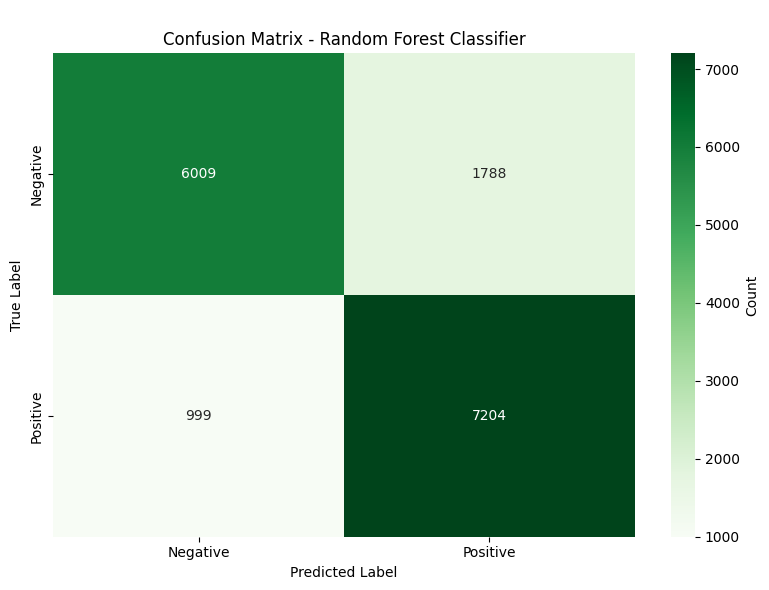

Confusion Matrix:
[[6009 1788]
 [ 999 7204]]

True Negatives: 6009
False Positives: 1788
False Negatives: 999
True Positives: 7204


In [13]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count'})
plt.title('\nConfusion Matrix - Random Forest Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('random_forest_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix:\n{cm}")
print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

## Step 9: Feature Importance

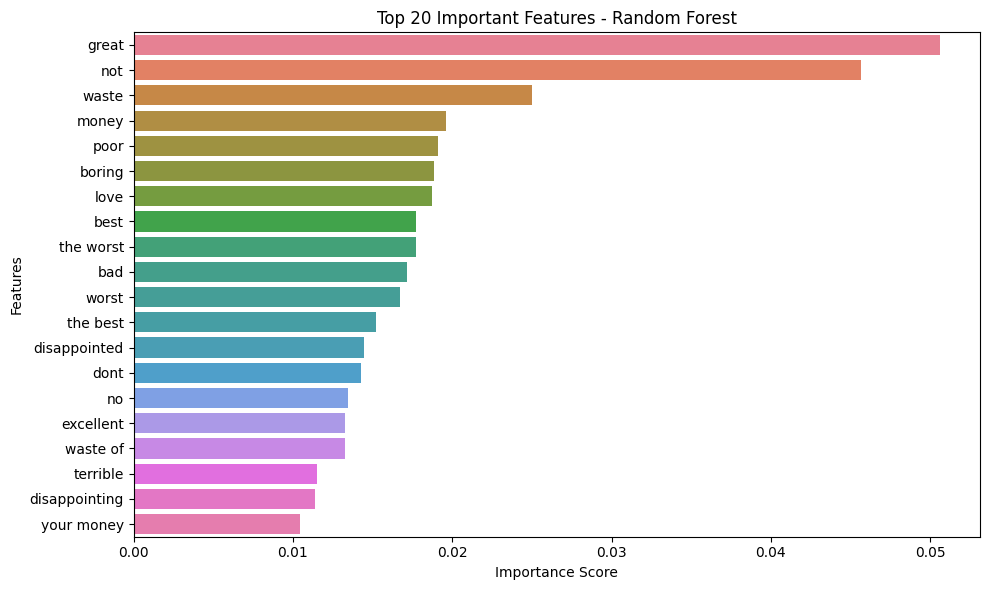


Top 20 Important Features:
      feature  importance
        great    0.050600
          not    0.045649
        waste    0.024979
        money    0.019606
         poor    0.019107
       boring    0.018868
         love    0.018700
         best    0.017754
    the worst    0.017732
          bad    0.017136
        worst    0.016721
     the best    0.015205
 disappointed    0.014470
         dont    0.014256
           no    0.013473
    excellent    0.013292
     waste of    0.013265
     terrible    0.011533
disappointing    0.011384
   your money    0.010415


In [14]:
# Get feature importance
feature_names = tfidf_vectorizer.get_feature_names_out()
feature_importance = rf_classifier.feature_importances_
# Create DataFrame for better visualization
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False).head(20)
# Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='husl')
plt.title('Top 20 Important Features - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('random_forest_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nTop 20 Important Features:")
print(importance_df.to_string(index=False))

## Step 10: Model Summary

In [15]:
print("RANDOM FOREST MODEL SUMMARY")
print(f"\nModel Parameters:")
print(f"  - Number of Estimators: {rf_classifier.n_estimators}")
print(f"  - Max Depth: {rf_classifier.max_depth}")
print(f"  - Min Samples Split: {rf_classifier.min_samples_split}")
print(f"  - Min Samples Leaf: {rf_classifier.min_samples_leaf}")
print(f"  - Max Features: {rf_classifier.max_features}")
print(f"\nFeature Engineering:")
print(f"  - Vectorizer: TF-IDF")
print(f"  - Max Features: 5000")
print(f"  - N-gram Range: (1, 2)")
print(f"  - Min Document Frequency: 5")
print(f"  - Max Document Frequency: 0.8")
print(f"\nPerformance:")
print(f"  - Accuracy:  {accuracy:.4f}")
print(f"  - Precision: {precision:.4f}")
print(f"  - Recall:    {recall:.4f}")
print(f"  - F1-Score:  {f1:.4f}")
print(f"  - Training Time: {training_time:.4f} seconds")

RANDOM FOREST MODEL SUMMARY

Model Parameters:
  - Number of Estimators: 200
  - Max Depth: 20
  - Min Samples Split: 10
  - Min Samples Leaf: 5
  - Max Features: sqrt

Feature Engineering:
  - Vectorizer: TF-IDF
  - Max Features: 5000
  - N-gram Range: (1, 2)
  - Min Document Frequency: 5
  - Max Document Frequency: 0.8

Performance:
  - Accuracy:  0.8258
  - Precision: 0.8574
  - Recall:    0.7707
  - F1-Score:  0.8118
  - Training Time: 54.0355 seconds
